<a href="https://colab.research.google.com/github/prakhar362/MLDL-Lab/blob/main/MLDL8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import tensorflow as tf

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


STEP 1: Loading Dataset...
Training shape: (60000, 28, 28)
Testing shape: (10000, 28, 28)

STEP 2: Preprocessing...

STEP 3: Building CNN Model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)


STEP 4: Compiling Model...

STEP 5: Training Model...
Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 44s 56ms/step - accuracy: 0.9207 - loss: 0.2603 - val_accuracy: 0.9791 - val_loss: 0.0673
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 56ms/step - accuracy: 0.9734 - loss: 0.0863 - val_accuracy: 0.9877 - val_loss: 0.0440
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.9809 - loss: 0.0656 - val_accuracy: 0.9866 - val_loss: 0.0478
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.9839 - loss: 0.0523 - val_accuracy: 0.9896 - val_loss: 0.0404
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - accuracy: 0.9863 - loss: 0.0435 - val_accuracy: 0.9897 - val_loss: 0.0383
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - accuracy: 0.9892 - loss: 0.0363 - val_accuracy: 0.9902 - val_loss: 0.0352
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - accuracy: 0.9901 - loss: 0.0323 - val_accuracy: 0.9897 - val_loss: 0.0359
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━

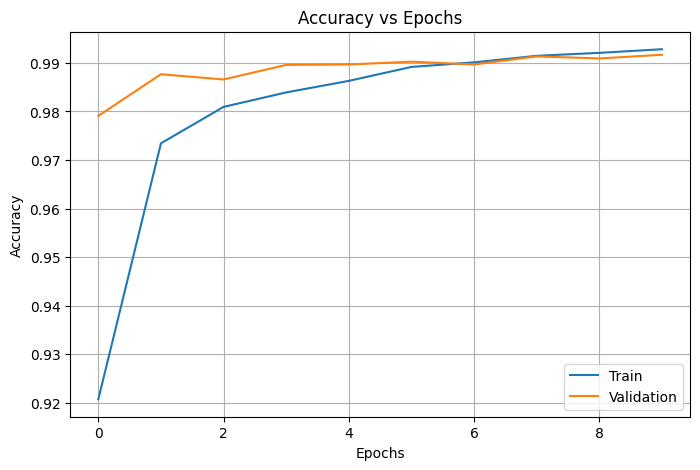

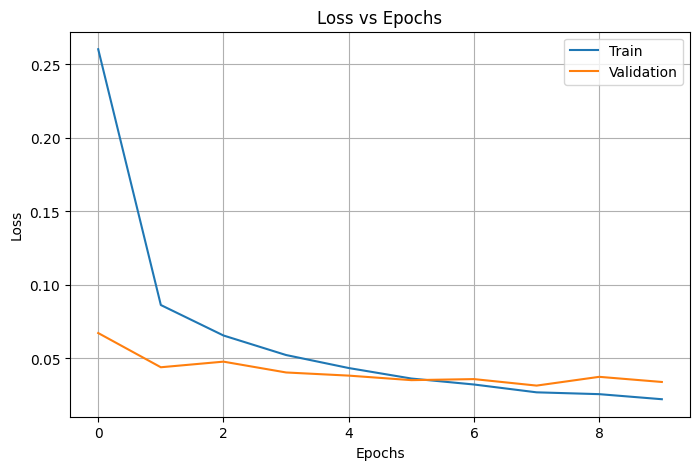

In [2]:
# ============================================================
# EXPERIMENT 8: CNN on MNIST Dataset
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# -------------------------------
# STEP 1: Load Dataset
# -------------------------------
print("STEP 1: Loading Dataset...")

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

# -------------------------------
# STEP 2: Preprocessing
# -------------------------------
print("\nSTEP 2: Preprocessing...")

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# -------------------------------
# STEP 3: Build Model
# -------------------------------
print("\nSTEP 3: Building CNN Model...")

model = Sequential([
    tf.keras.Input(shape=(28,28,1)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

model.summary()

# -------------------------------
# STEP 4: Compile Model
# -------------------------------
print("\nSTEP 4: Compiling Model...")

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -------------------------------
# STEP 5: Train Model
# -------------------------------
print("\nSTEP 5: Training Model...")

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

# -------------------------------
# STEP 6: Evaluate Model
# -------------------------------
print("\nSTEP 6: Evaluating Model...")

loss, acc = model.evaluate(X_test, y_test)

print(f"Test Accuracy: {acc*100:.2f}%")
print(f"Test Loss: {loss:.4f}")

# -------------------------------
# STEP 7: Accuracy Graph
# -------------------------------
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.grid(True)
plt.show()

# -------------------------------
# STEP 8: Loss Graph
# -------------------------------
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.grid(True)
plt.show()